In [1]:
import numpy as np
import pandas as pd
from modelens import RegressionAnalyzer, regression_models

In [2]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)

In [3]:
raw_data = pd.read_csv("dataset.csv")
df = raw_data.copy()

#### 1 - EDA + ETL

In [4]:
analyzer = RegressionAnalyzer(df, target="mpg")

In [5]:
analyzer.info()

In [6]:
# Check Invalid Data
df["horsepower"].unique()

<StringArray>
['130', '165', '150', '140', '198', '220', '215', '225', '190', '170', '160',
  '95',  '97',  '85',  '88',  '46',  '87',  '90', '113', '200', '210', '193',
   '?', '100', '105', '175', '153', '180', '110',  '72',  '86',  '70',  '76',
  '65',  '69',  '60',  '80',  '54', '208', '155', '112',  '92', '145', '137',
 '158', '167',  '94', '107', '230',  '49',  '75',  '91', '122',  '67',  '83',
  '78',  '52',  '61',  '93', '148', '129',  '96',  '71',  '98', '115',  '53',
  '81',  '79', '120', '152', '102', '108',  '68',  '58', '149',  '89',  '63',
  '48',  '66', '139', '103', '125', '133', '138', '135', '142',  '77',  '62',
 '132',  '84',  '64',  '74', '116',  '82']
Length: 94, dtype: str

In [7]:
# ? is Invalida Data in horsepower Column
df["horsepower"] = df["horsepower"].replace({"?": np.nan}).astype(float)
df = df.dropna(subset=["horsepower"])
df["horsepower"].unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
       100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,  65.,
        69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137., 158.,
       167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,  78.,
        52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,  81.,
        79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,  48.,
        66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62., 132.,
        84.,  64.,  74., 116.,  82.])

In [8]:
# One Hot Encoding
df = pd.get_dummies(
    df,
    columns=["origin"],
    prefix="origin",
    drop_first=True,
    dtype=int,
)

In [9]:
# Remove UnUsed Columns
if "car name" in df.columns:
    df = df.drop(columns=["car name"])

In [10]:
analyzer.reinit(df=df, target="mpg")

In [11]:
analyzer.info()

In [12]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_2,origin_3
0,18.0,8,307.0,130.0,3504,12.0,70,0,0
1,15.0,8,350.0,165.0,3693,11.5,70,0,0
2,18.0,8,318.0,150.0,3436,11.0,70,0,0
3,16.0,8,304.0,150.0,3433,12.0,70,0,0
4,17.0,8,302.0,140.0,3449,10.5,70,0,0


#### 2 - Comparing Models

In [13]:
target = "mpg"
X = df.drop(columns=[target])
y = df[target]
features = df.columns.drop(target)

In [14]:
models = regression_models()

# analyzer.compare_models(
#     models=models,
#     features=features,
#     export_html=True,
#     file_name="01-base-model-comparing",
# )

#### Model Selection for Tuning
***1. CatBoost ***: بهترین ترین و تست

***2. Polynomial Regression D2 *** بهترین سرعت فیت و پردیکت

***3. LightGBM *** بهترین سرعت فیت

***4. Gradient Boosting *** بهترین سرعت پردیکت

In [15]:
selected_models = regression_models(
    smodels=[
        # "CatBoost",
        "Polynomial Regression",
        "LightGBM",
        "Gradient Boosting",
    ]
)


analyzer.compare_models(
    models=selected_models,
    features=features,
    export_html=True,
    file_name="02-selected-model",
)

'✓ Report generated successfully: html_reports/compare_models'

In [16]:
param_grids = {
    # "CatBoost": {
    #     "iterations": [300, 500, 1000],
    #     # "depth": [4, 6, 8],
    #     # "learning_rate": [0.03, 0.05, 0.1],
    #     # "l2_leaf_reg": [1, 3, 5],
    # },
    "Polynomial Regression": {
        "polynomial__degree": [2, 3, 4],
    },
    "LightGBM": {
        "n_estimators": [100, 300, 500],
        # "learning_rate": [0.03, 0.1],
        # "num_leaves": [15, 31, 63],
        # "max_depth": [-1, 10],
        # "min_child_samples": [10, 20],
        # "colsample_bytree": [0.8, 1.0],
    },
    "Gradient Boosting": {
        "n_estimators": [100, 300, 500],
        # "learning_rate": [0.03, 0.05, 0.1],
        # "max_depth": [2, 3, 5],
        # "min_samples_split": [2, 5],
        # "min_samples_leaf": [1, 2, 4],
    },
}

# for name, model in selected_models.items():

#     analyzer.tune_model(
#         model=model,
#         features=features,
#         param_grid=param_grids[name],
#         export_html=True,
#         file_name=f"{name.lower().replace(' ', '-')}",
#     )

#### Decrease Feature

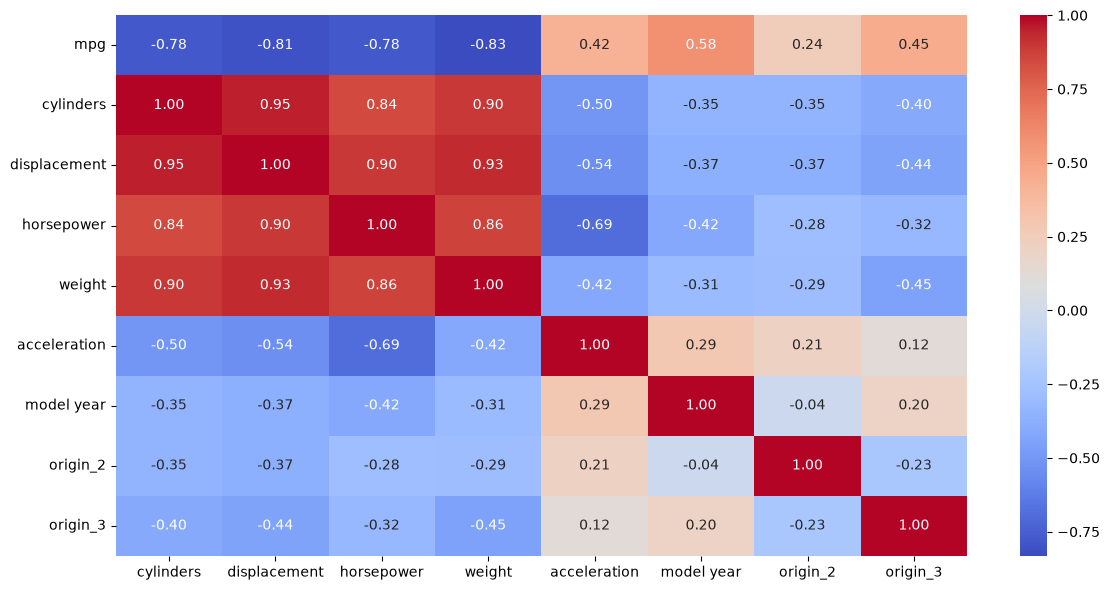

In [17]:
_, suspicious_features = analyzer.correlation(features=features)

In [18]:
analyzer.vif(features=features)

,Feature,VIF
1,displacement,22.937950
3,weight,11.074349
0,cylinders,10.737771
2,horsepower,9.957265
4,acceleration,2.625906
7,origin_3,1.762692
6,origin_2,1.649271
5,model year,1.301373


In [19]:
from catboost import CatBoostRegressor

selected_models["CatBoost"] = CatBoostRegressor(
    depth=6, iterations=300, l2_leaf_reg=1, learning_rate=0.05
)

In [20]:
# for name, model in selected_models.items():
#     analyzer.evaluate_single_feature_removal(
#         model=model,
#         features=features,
#         export_html=True,
#         file_name=f"{name.lower().replace(' ', '-')}",
#     )

In [21]:
# for name, model in selected_models.items():
#     analyzer.evaluate_feature_removal_combinations(
#         model=model,
#         features=features,
#         candidates=suspicious_features,
#         export_html=True,
#         file_name=f"{name.lower().replace(' ', '-')}",
#     )

In [22]:
selected_model = models["CatBoost"]

In [23]:
selected_features = [
    "model year",
    "weight",
]

analyzer.compare_feature_sets(
    model=selected_model,
    feature_sets={
        "All Features": features,
        "Model Year + Weight": selected_features,
    },
    export_html=True,
    file_name="catboost_feature_comparison",
)

'✓ Report generated successfully: html_reports/compare_feature_sets/catboost_feature_comparison.html'

In [ ]:
analyzer.residual_analysis(model=selected_model,export_html=True)

In [ ]:
analyzer.learning_curve(model=selected_model)